# Imports

In [ ]:
# !mkdir /root/.config/kaggle/
# !mv kaggle.json /root/.config/kaggle/

In [ ]:
!pip install datasets conllu

In [ ]:
!pip install sklearn-crfsuite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.7 MB/s eta 0:00:00


In [ ]:
import urllib.request
from conllu import parse
import random

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

from collections import defaultdict, Counter
import numpy as np
import math

import sklearn_crfsuite
from sklearn_crfsuite import metrics
import scipy.stats

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Dataset download & helper functions

In [ ]:
# Download official UD files
urls = {
    "train": "https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-train.conllu",
    "dev": "https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-dev.conllu",
    "test": "https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-test.conllu"
}

for name, url in urls.items():
    urllib.request.urlretrieve(url, f"{name}.conllu")
    print(f"Downloaded {name}.conllu")

def load_sentences(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        data = parse(f.read())
    return [[(t["form"], t["upos"]) for t in sent] for sent in data]

train_sents = load_sentences("train.conllu")
dev_sents = load_sentences("dev.conllu")
test_sents = load_sentences("test.conllu")

# Downsample for Colab memory (120k tokens target)
random.seed(42)
random.shuffle(train_sents)
token_count = 0
downsampled_train = []
for sent in train_sents:
    if token_count + len(sent) > 120000:
        break
    downsampled_train.append(sent)
    token_count += len(sent)

train_sents = downsampled_train
print(f"Train: {len(train_sents)} sents, {token_count} tokens")
print(f"Dev: {len(dev_sents)} sents")
print(f"Test: {len(test_sents)} sents")
print(f"Sample: {train_sents[0][:5]}")

Downloaded train.conllu
Downloaded dev.conllu
Downloaded test.conllu
Train: 7262 sents, 119967 tokens
Dev: 2001 sents
Test: 2077 sents
Sample: [('Do', 'AUX'), ('you', 'PRON'), ('speak', 'VERB'), ('a', 'DET'), ('foreign', 'ADJ')]


In [ ]:
test_metadata = []
total_words = 0
for sent_idx, sent in enumerate(test_sents):
  length = len(sent)
  length_bin = None
  if length <= 10:
    length_bin = 'short'
  elif length <= 25:
    length_bin = 'medium'
  else:
    length_bin = 'long'

  total_words += length

  test_metadata.append({'sent_id': sent_idx, 'length': len(sent), 'length_bin': length_bin})

print(f'Average sentence length: {total_words / len(test_sents)}')

Average sentence length: 12.253249879634087


In [ ]:
FULL_MODEL_NAMES = {
    'hmm': 'HMM + Viterbi',
    'perc':'Averaged Perceptron',
    'crf': 'CRF',
    'bilstm': 'BiLSTM'
}

In [ ]:
# ============================================
# EVALUATION FRAMEWORK
# ============================================
def evaluate_tagger(tagger_function, sentences, short_model_name=None, verbose=True):
    """
    Comprehensive evaluation of a POS tagger.

    Args:
        tagger_function: Function that takes list of words, returns list of predicted tags
        sentences: List of sentences, where each sentence is a list of (word, tag) tuples
        short_model_name: Model name to store the number of correct predictions in metadata
        verbose: Print detailed results

    Returns:
        accuracy: Overall accuracy (float)
        all_gold: Flat list of all gold tags
        all_pred: Flat list of all predicted tags
    """
    correct = 0
    total = 0

    all_gold = []
    all_pred = []

    # For per-tag metrics
    tag_correct = defaultdict(int)
    tag_total = defaultdict(int)

    # For sentence-level analysis
    sentence_accuracies = []

    # For unknown word analysis (words not seen in training)
    known_words_correct = 0
    known_words_total = 0
    unknown_words_correct = 0
    unknown_words_total = 0

    for sent_idx, sent in enumerate(sentences):
        words = [w for w, _ in sent]
        gold_tags = [t for _, t in sent]

        # Get predictions
        try:
            pred_tags = tagger_function(words)
        except Exception as e:
            print(f"Error predicting sentence {sent_idx}: {e}")
            # Fallback: predict most common tag
            pred_tags = ['NOUN'] * len(words)

        # Ensure same length
        if len(pred_tags) != len(gold_tags):
            print(f"Warning: Length mismatch at sentence {sent_idx}")
            pred_tags = pred_tags[:len(gold_tags)] if len(pred_tags) > len(gold_tags) else pred_tags + ['NOUN'] * (len(gold_tags) - len(pred_tags))

        # Calculate sentence-level accuracy
        sent_correct = sum(1 for g, p in zip(gold_tags, pred_tags) if g == p)
        sent_acc = sent_correct / len(gold_tags) if gold_tags else 0
        sentence_accuracies.append(sent_acc)

        # Update overall counts
        for i, (word, gold, pred) in enumerate(zip(words, gold_tags, pred_tags)):
            all_gold.append(gold)
            all_pred.append(pred)

            tag_total[gold] += 1
            if gold == pred:
                correct += 1
                tag_correct[gold] += 1

        # Store per-sentence results in metadata if provided
        if short_model_name is not None:
            test_metadata[sent_idx][f'{short_model_name}_correct'] = sent_correct

        total += len(gold_tags)

    # Calculate overall accuracy
    accuracy = correct / total if total > 0 else 0

    if verbose:
        print("\n" + "="*60)
        print("EVALUATION RESULTS")
        print("="*60)
        print(f"Overall Accuracy:        {accuracy:.4f} ({correct}/{total})")
        print(f"Mean Sentence Accuracy:   {np.mean(sentence_accuracies):.4f}")
        print(f"Std Sentence Accuracy:    {np.std(sentence_accuracies):.4f}")

        # Per-tag accuracy (for tags with enough samples)
        print("\n--- Per-Tag Accuracy ---")
        print(f"{'Tag':<8} {'Correct':<10} {'Total':<10} {'Accuracy':<10}")
        print("-"*40)

        # Sort by frequency
        sorted_tags = sorted(tag_total.keys(), key=lambda t: tag_total[t], reverse=True)
        for tag in sorted_tags:
            if tag_total[tag] >= 10:  # Only show tags with sufficient samples
                acc = tag_correct[tag] / tag_total[tag]
                print(f"{tag:<8} {tag_correct[tag]:<10} {tag_total[tag]:<10} {acc:.4f}")

        # Most common errors
        print("\n--- Top 10 Most Common Errors ---")
        errors = defaultdict(int)
        for g, p in zip(all_gold, all_pred):
            if g != p:
                errors[(g, p)] += 1

        sorted_errors = sorted(errors.items(), key=lambda x: x[1], reverse=True)
        print(f"{'Gold':<10} {'Pred':<10} {'Count':<10}")
        print("-"*35)
        for (gold, pred), count in sorted_errors[:10]:
            print(f"{gold:<10} {pred:<10} {count:<10}")

    return accuracy, all_gold, all_pred


def evaluate_by_bins(short_model_name, by_bin):
    """
    Analyze accuracy by bin.
    Uses the metadata populated during evaluate_tagger calls.
    """
    bins = defaultdict(lambda: {'correct': 0, 'total': 0})

    for sent_data in test_metadata:
        bin_name = sent_data.get(by_bin, 'unknown')
        length = sent_data.get('length', 0)

        bins[bin_name]['correct'] += sent_data.get(f'{short_model_name}_correct', 0)
        bins[bin_name]['total'] += length

    formated = None
    if by_bin == 'length_bin':
        formated = "Sentence Length"
    else:
        formated = "Out of Vocabulary number"
    print(f"\n--- {FULL_MODEL_NAMES[short_model_name]}: Accuracy by {formated} ---")
    print(f"{'Bin':<20}\t{'Accuracy':<12}\t{'Tokens':<10}")
    print("-"*45)

    overall_correct = 0
    overall_total = 0

    for bin_name in sorted(bins.keys()):
        c = bins[bin_name]['correct']
        t = bins[bin_name]['total']
        acc = c / t if t > 0 else 0
        print(f"{bin_name:<20}\t{acc:.4f}\t\t{t}")
        overall_correct += c
        overall_total += t

    if overall_total > 0:
        print("-"*45)
        print(f"{'OVERALL':<20}\t{overall_correct/overall_total:.4f}\t\t{overall_total}")

    return bins

# MODEL 1: HMM + VITERBI

In [ ]:
class HMMTagger:
    def __init__(self, smoothing=0.01):
        self.smoothing = smoothing
        self.tags = set()
        self.vocab = set()

        # Probabilities (log space to avoid underflow)
        self.log_transition = {}      # P(tag_i | tag_{i-1})
        self.log_emission = {}        # P(word | tag)
        self.log_initial = {}         # P(tag | START)

        # For handling unknown words
        self.tag_unigram = {}         # P(tag) fallback
        self.word_suffixes = Counter() # Suffix-based fallback

    def train(self, sentences):
        """Train HMM on list of (word, tag) sentences."""
        # Counters
        transition_counts = defaultdict(Counter)  # prev_tag -> tag -> count
        emission_counts = defaultdict(Counter)     # tag -> word -> count
        initial_counts = Counter()                 # first tag in sentence
        tag_counts = Counter()                     # total tag occurrences

        # Suffix patterns for unknown words (last 3 chars)
        suffix_by_tag = defaultdict(Counter)

        for sent in sentences:
            # Handle start of sentence
            first_tag = sent[0][1]
            initial_counts[first_tag] += 1

            # Process each word
            for i, (word, tag) in enumerate(sent):
                self.tags.add(tag)
                self.vocab.add(word)
                tag_counts[tag] += 1
                emission_counts[tag][word] += 1

                # Collect suffix info (last 3 chars, lowercased)
                suffix = word.lower()[-3:] if len(word) >= 3 else word.lower()
                suffix_by_tag[tag][suffix] += 1

                # Transitions (previous tag -> current tag)
                if i > 0:
                    prev_tag = sent[i-1][1]
                    transition_counts[prev_tag][tag] += 1

        # Convert counts to log probabilities with smoothing
        self.tags = list(self.tags)
        n_tags = len(self.tags)

        # Initial probabilities
        total_starts = sum(initial_counts.values())
        for tag in self.tags:
            count = initial_counts.get(tag, 0)
            self.log_initial[tag] = math.log((count + self.smoothing) /
                                             (total_starts + self.smoothing * n_tags))

        # Transition probabilities
        for prev_tag in self.tags:
            self.log_transition[prev_tag] = {}
            total_trans = sum(transition_counts[prev_tag].values())
            for curr_tag in self.tags:
                count = transition_counts[prev_tag].get(curr_tag, 0)
                prob = (count + self.smoothing) / (total_trans + self.smoothing * n_tags)
                self.log_transition[prev_tag][curr_tag] = math.log(prob)

        # Emission probabilities
        total_tokens = sum(tag_counts.values())
        for tag in self.tags:
            self.log_emission[tag] = {}
            total_emit = sum(emission_counts[tag].values())
            for word in emission_counts[tag]:
                count = emission_counts[tag][word]
                prob = (count + self.smoothing) / (total_emit + self.smoothing * len(self.vocab))
                self.log_emission[tag][word] = math.log(prob)
            # Store fallback probability for unseen words
            self.log_emission[tag]['__UNK__'] = math.log(self.smoothing /
                                                         (total_emit + self.smoothing * len(self.vocab)))

        # Tag unigram for fallback
        for tag in self.tags:
            self.tag_unigram[tag] = tag_counts[tag] / total_tokens

        # Suffix model for unknown words
        self.suffix_model = {}
        for tag in self.tags:
            total_suffix = sum(suffix_by_tag[tag].values())
            self.suffix_model[tag] = {}
            for suffix, count in suffix_by_tag[tag].items():
                self.suffix_model[tag][suffix] = count / total_suffix

    def _get_emission_prob(self, word, tag):
        """Get emission probability, handling unknown words."""
        if word in self.log_emission[tag]:
            return self.log_emission[tag][word]

        # Unknown word: try suffix model
        suffix = word.lower()[-3:] if len(word) >= 3 else word.lower()
        if suffix in self.suffix_model[tag]:
            # Weight suffix probability with a small constant
            suffix_prob = self.suffix_model[tag][suffix] * 0.1
            return math.log(suffix_prob) if suffix_prob > 0 else self.log_emission[tag]['__UNK__']

        return self.log_emission[tag]['__UNK__']

    def predict(self, words):
        """Viterbi decoding for a sequence of words."""
        if not words:
            return []

        n = len(words)

        # Viterbi table: dp[i][tag] = max log probability ending at position i with tag
        dp = [{} for _ in range(n)]
        # Backpointers: bp[i][tag] = previous tag
        bp = [{} for _ in range(n)]

        # Initialization (first word)
        for tag in self.tags:
            emit_prob = self._get_emission_prob(words[0], tag)
            dp[0][tag] = self.log_initial[tag] + emit_prob
            bp[0][tag] = None

        # Recursion
        for i in range(1, n):
            word = words[i]
            for curr_tag in self.tags:
                max_prob = float('-inf')
                best_prev = None
                emit_prob = self._get_emission_prob(word, curr_tag)

                for prev_tag in self.tags:
                    trans_prob = self.log_transition[prev_tag][curr_tag]
                    prob = dp[i-1][prev_tag] + trans_prob + emit_prob
                    if prob > max_prob:
                        max_prob = prob
                        best_prev = prev_tag

                dp[i][curr_tag] = max_prob
                bp[i][curr_tag] = best_prev

        # Termination: find best final tag
        best_final_tag = max(self.tags, key=lambda t: dp[n-1][t])

        # Backtrack
        tags = [best_final_tag]
        for i in range(n-1, 0, -1):
            prev_tag = bp[i][tags[0]]
            tags.insert(0, prev_tag)

        return tags

# Train and evaluate
print("Training HMMs with different smoothings...")
hmm001 = HMMTagger(smoothing=0.01)
hmm001.train(train_sents)

hmm001_acc, hmm_gold, hmm001_pred = evaluate_tagger(lambda words: hmm001.predict(words), dev_sents, verbose=False)

hmm0005 = HMMTagger(smoothing=0.001)
hmm0005.train(train_sents)

hmm0005_acc, hmm_gold, hmm0005_pred = evaluate_tagger(lambda words: hmm0005.predict(words), dev_sents, verbose=False)

hmm002 = HMMTagger(smoothing=0.02)
hmm002.train(train_sents)

hmm002_acc, hmm_gold, hmm002_pred = evaluate_tagger(lambda words: hmm002.predict(words), dev_sents, verbose=False)


dev_words = [w for w, _ in dev_sents[0]]
dev_gold = [t for _, t in dev_sents[0]]

show_lim = min(len(dev_words), 8)

print(f"\nExample prediction:")
print(f"Words:\t\t{dev_words[:show_lim]}")
print(f"Gold:\t\t{dev_gold[:show_lim]}")
print(f"HMM(0.01):\t{hmm001_pred[:show_lim]}")
print(f"HMM(0.001):\t{hmm0005_pred[:show_lim]}")
print(f"HMM(0.02):\t{hmm002_pred[:show_lim]}")

print("\n\n")

print(f"Acc HMM(0.01): {hmm001_acc}")
print(f"Acc HMM(0.005):  {hmm0005_acc}")
print(f"Acc HMM(0.02):  {hmm002_acc}")

Training HMMs with different smoothings...

Example prediction:
Words:		['From', 'the', 'AP', 'comes', 'this', 'story', ':']
Gold:		['ADP', 'DET', 'PROPN', 'VERB', 'DET', 'NOUN', 'PUNCT']
HMM(0.01):	['ADP', 'DET', 'NOUN', 'VERB', 'DET', 'NOUN', 'PUNCT']
HMM(0.001):	['ADP', 'DET', 'NOUN', 'VERB', 'DET', 'NOUN', 'PUNCT']
HMM(0.02):	['ADP', 'DET', 'NOUN', 'VERB', 'DET', 'NOUN', 'PUNCT']



Acc HMM(0.01): 0.840062720501764
Acc HMM(0.005):  0.8412387299098393
Acc HMM(0.02):  0.8389651117208937


In [ ]:
hmm = hmm001

# Test on a few examples
test_words = [w for w, _ in test_sents[0]]
test_gold = [t for _, t in test_sents[0]]
test_pred = hmm.predict(test_words)

print(f"\nExample prediction:")
print(f"Words: {test_words[:8]}")
print(f"Gold:  {test_gold[:8]}")
print(f"Pred:  {test_pred[:8]}")

hmm_metadata = [{} for i in range(len(test_sents))]
hmm_acc, hmm_gold, hmm_pred = evaluate_tagger(lambda words: hmm.predict(words), test_sents, short_model_name='hmm')
print(f"\nHMM Test Accuracy: {hmm_acc:.4f}")


Example prediction:
Words: ['What', 'if', 'Google', 'Morphed', 'Into', 'GoogleOS', '?']
Gold:  ['PRON', 'SCONJ', 'PROPN', 'VERB', 'ADP', 'PROPN', 'PUNCT']
Pred:  ['SCONJ', 'SCONJ', 'PROPN', 'VERB', 'ADP', 'NOUN', 'PUNCT']

EVALUATION RESULTS
Overall Accuracy:        0.8450 (21504/25450)
Mean Sentence Accuracy:   0.8263
Std Sentence Accuracy:    0.2117

--- Per-Tag Accuracy ---
Tag      Correct    Total      Accuracy  
----------------------------------------
NOUN     3211       4123       0.7788
PUNCT    3046       3096       0.9839
VERB     2044       2606       0.7843
PRON     2028       2165       0.9367
PROPN    1197       2075       0.5769
ADP      1882       2025       0.9294
DET      1830       1897       0.9647
ADJ      1304       1788       0.7293
AUX      1477       1543       0.9572
ADV      948        1191       0.7960
CCONJ    724        736        0.9837
PART     602        649        0.9276
NUM      425        542        0.7841
SCONJ    246        384        0.6406
_   

In [ ]:
hmm_length_bins = evaluate_by_bins('hmm', by_bin='length_bin')


--- HMM + Viterbi: Accuracy by Sentence Length ---
Bin                 	Accuracy    	Tokens    
---------------------------------------------
long                	0.8457		8242
medium              	0.8542		11430
short               	0.8255		5778
---------------------------------------------
OVERALL             	0.8450		25450


# MODEL 2: AVERAGED PERCEPTRON

In [ ]:
class AveragedPerceptronTagger:
    def __init__(self, iterations=5, seed=42):
        self.iterations = iterations
        self.seed = seed

        # Weight dictionaries
        self.weights = defaultdict(float)      # Current weights
        self.totals = defaultdict(float)       # Accumulated weights (for averaging)
        self.timestamps = defaultdict(int)     # Last update time
        self.current_time = 0

        self.tags = set()
        self.tag_list = []

    def _get_features(self, words, i, prev_tag, prev_prev_tag):
        """Extract features for word at position i."""
        features = []
        w = words[i]
        w_lower = w.lower()

        # Current word features
        features.append(f'w={w_lower}')
        features.append(f'prefix1={w_lower[:1]}')
        features.append(f'prefix2={w_lower[:2]}' if len(w) >= 2 else f'prefix2={w_lower}')
        features.append(f'prefix3={w_lower[:3]}' if len(w) >= 3 else f'prefix3={w_lower}')
        features.append(f'suffix1={w_lower[-1:]}')
        features.append(f'suffix2={w_lower[-2:]}' if len(w) >= 2 else f'suffix2={w_lower}')
        features.append(f'suffix3={w_lower[-3:]}' if len(w) >= 3 else f'suffix3={w_lower}')
        features.append(f'is_digit={any(c.isdigit() for c in w)}')
        features.append(f'is_capitalized={w[0].isupper() if w else False}')
        features.append(f'has_hyphen={"-" in w}')

        # Context features (neighboring words)
        if i > 0:
            prev_w = words[i-1].lower()
            features.append(f'prev_w={prev_w}')
            features.append(f'prev_suffix={prev_w[-2:]}' if len(prev_w) >= 2 else '')
        if i < len(words) - 1:
            next_w = words[i+1].lower()
            features.append(f'next_w={next_w}')
            features.append(f'next_suffix={next_w[-2:]}' if len(next_w) >= 2 else '')

        # Tag transition features
        if prev_tag is not None:
            features.append(f'prev_tag={prev_tag}')
        if prev_prev_tag is not None:
            features.append(f'prev_prev_tag={prev_prev_tag}')
        if prev_tag is not None and prev_prev_tag is not None:
            features.append(f'trigram={prev_prev_tag}+{prev_tag}')

        return features

    def _score(self, features, tag):
        """Compute score for a tag given features."""
        score = 0.0
        for feat in features:
            score += self.weights[(feat, tag)]
        return score

    def _update(self, features, true_tag, pred_tag):
        """Update weights for a single mistake."""
        self.current_time += 1

        def update_weight(key, delta):
            # Update accumulated totals (for averaging)
            self.totals[key] += self.weights[key] * (self.current_time - self.timestamps[key])
            self.timestamps[key] = self.current_time
            self.weights[key] += delta

        for feat in features:
            update_weight((feat, true_tag), 1.0)
            update_weight((feat, pred_tag), -1.0)

    def train(self, sentences):
        """Train averaged perceptron."""
        # First pass: collect all tags
        for sent in sentences:
            for _, tag in sent:
                self.tags.add(tag)
        self.tag_list = list(self.tags)

        random.seed(self.seed)

        for iteration in range(self.iterations):
            print(f"  Perceptron iteration {iteration + 1}/{self.iterations}")

            # Shuffle sentences each epoch
            shuffled = sentences[:]
            random.shuffle(shuffled)

            for sent_idx, sent in enumerate(shuffled):
                words = [w for w, _ in sent]
                gold_tags = [t for _, t in sent]

                prev_tag = None
                prev_prev_tag = None

                for i, (word, gold_tag) in enumerate(sent):
                    features = self._get_features(words, i, prev_tag, prev_prev_tag)

                    # Predict best tag
                    best_tag = None
                    best_score = float('-inf')
                    for tag in self.tag_list:
                        score = self._score(features, tag)
                        if score > best_score:
                            best_score = score
                            best_tag = tag

                    # Update if wrong
                    if best_tag != gold_tag:
                        self._update(features, gold_tag, best_tag)

                    # Update tag history
                    prev_prev_tag = prev_tag
                    prev_tag = gold_tag

                # Progress indicator
                # if (sent_idx + 1) % 1000 == 0:
                #     print(f"    Processed {sent_idx + 1} sentences")

        # Finalize averaging
        self._finalize_weights()

    def _finalize_weights(self):
        """Average all weights over time."""
        self.current_time += 1
        for key in list(self.weights.keys()):
            self.totals[key] += self.weights[key] * (self.current_time - self.timestamps[key])
        # Replace weights with averaged versions
        for key in self.totals:
            self.weights[key] = self.totals[key] / self.current_time

    def predict(self, words):
        """Greedy decoding for a sequence."""
        if not words:
            return []

        tags = []
        prev_tag = None
        prev_prev_tag = None

        for i, word in enumerate(words):
            features = self._get_features(words, i, prev_tag, prev_prev_tag)

            best_tag = None
            best_score = float('-inf')
            for tag in self.tag_list:
                score = self._score(features, tag)
                if score > best_score:
                    best_score = score
                    best_tag = tag

            tags.append(best_tag)
            prev_prev_tag = prev_tag
            prev_tag = best_tag

        return tags

# Train and evaluate
print("\nTraining Averaged Perceptron with 3 iterations...")
perceptron3 = AveragedPerceptronTagger(iterations=3)
perceptron3.train(train_sents)

perc3_acc, perc_gold, perc3_pred = evaluate_tagger(lambda words: perceptron3.predict(words), dev_sents, verbose=False)


print("\nTraining Averaged Perceptron with 5 iterations...")
perceptron5 = AveragedPerceptronTagger(iterations=5)
perceptron5.train(train_sents)

perc5_acc, perc_gold, perc5_pred = evaluate_tagger(lambda words: perceptron5.predict(words), dev_sents, verbose=False)

print("\nTraining Averaged Perceptron with 7 iterations...")
perceptron7 = AveragedPerceptronTagger(iterations=7)
perceptron7.train(train_sents)

perc7_acc, perc_gold, perc7_pred = evaluate_tagger(lambda words: perceptron7.predict(words), dev_sents, verbose=False)

dev_words = [w for w, _ in dev_sents[0]]
dev_gold = [t for _, t in dev_sents[0]]

show_lim = min(len(dev_words), 8)

print(f"\nExample prediction:")
print(f"Words:\t\t{dev_words[:show_lim]}")
print(f"Gold:\t\t{dev_gold[:show_lim]}")
print(f"Perc(3):\t{perc3_pred[:show_lim]}")
print(f"Perc(5):\t{perc5_pred[:show_lim]}")
print(f"Perc(7):\t{perc7_pred[:show_lim]}")

print("\n\n")

print(f"Acc Perc(3): {perc3_acc}")
print(f"Acc Perc(5):  {perc5_acc}")
print(f"Acc Perc(7):  {perc7_acc}")


Training Averaged Perceptron with 3 iterations...
  Perceptron iteration 1/3
  Perceptron iteration 2/3
  Perceptron iteration 3/3

Training Averaged Perceptron with 5 iterations...
  Perceptron iteration 1/5
  Perceptron iteration 2/5
  Perceptron iteration 3/5
  Perceptron iteration 4/5
  Perceptron iteration 5/5

Training Averaged Perceptron with 7 iterations...
  Perceptron iteration 1/7
  Perceptron iteration 2/7
  Perceptron iteration 3/7
  Perceptron iteration 4/7
  Perceptron iteration 5/7
  Perceptron iteration 6/7
  Perceptron iteration 7/7

Example prediction:
Words:		['From', 'the', 'AP', 'comes', 'this', 'story', ':']
Gold:		['ADP', 'DET', 'PROPN', 'VERB', 'DET', 'NOUN', 'PUNCT']
Perc(3):	['ADP', 'DET', 'NOUN', 'VERB', 'DET', 'NOUN', 'PUNCT']
Perc(5):	['ADP', 'DET', 'NOUN', 'VERB', 'DET', 'NOUN', 'PUNCT']
Perc(7):	['ADP', 'DET', 'NOUN', 'VERB', 'DET', 'NOUN', 'PUNCT']



Acc Perc(3): 0.9246961975695805
Acc Perc(5):  0.9286162289298314
Acc Perc(7):  0.9299882399059193


In [ ]:
perceptron = perceptron5

# Test prediction
test_pred_perc = perceptron.predict(test_words)
print(f"\nExample prediction:")
print(f"Words: {test_words[:8]}")
print(f"Gold:  {test_gold[:8]}")
print(f"Pred:  {test_pred_perc[:8]}")

perc_metadata = [{} for i in range(len(test_sents))]
perc_acc, perc_gold, perc_pred = evaluate_tagger(lambda words: perceptron.predict(words), test_sents, short_model_name='perc')
print(f"\nPerceptron Test Accuracy: {perc_acc:.4f}")


Example prediction:
Words: ['What', 'if', 'Google', 'Morphed', 'Into', 'GoogleOS', '?']
Gold:  ['PRON', 'SCONJ', 'PROPN', 'VERB', 'ADP', 'PROPN', 'PUNCT']
Pred:  ['PRON', 'SCONJ', 'PROPN', 'VERB', 'ADP', 'PROPN', 'PUNCT']

EVALUATION RESULTS
Overall Accuracy:        0.9292 (23649/25450)
Mean Sentence Accuracy:   0.9157
Std Sentence Accuracy:    0.1600

--- Per-Tag Accuracy ---
Tag      Correct    Total      Accuracy  
----------------------------------------
NOUN     3703       4123       0.8981
PUNCT    3079       3096       0.9945
VERB     2458       2606       0.9432
PRON     2112       2165       0.9755
PROPN    1735       2075       0.8361
ADP      1931       2025       0.9536
DET      1862       1897       0.9815
ADJ      1492       1788       0.8345
AUX      1520       1543       0.9851
ADV      1059       1191       0.8892
CCONJ    730        736        0.9918
PART     630        649        0.9707
NUM      520        542        0.9594
SCONJ    289        384        0.7526
_   

In [ ]:
perc_length_bins = evaluate_by_bins('perc', by_bin='length_bin')


--- Averaged Perceptron: Accuracy by Sentence Length ---
Bin                 	Accuracy    	Tokens    
---------------------------------------------
long                	0.9330		8242
medium              	0.9346		11430
short               	0.9131		5778
---------------------------------------------
OVERALL             	0.9292		25450


# MODEL 3: CONDITIONAL RANDOM FIELD (CRF)

In [ ]:
class CRFTagger:
    def __init__(self, algorithm='lbfgs', max_iterations=100, c1=0.1, c2=0.1):
        self.algorithm = algorithm
        self.max_iterations = max_iterations
        self.c1 = c1  # L1 regularization
        self.c2 = c2  # L2 regularization
        self.model = None
        self.tags = set()

    def _word2features(self, sent, i):
        """Extract features for word at position i."""
        word = sent[i][0]
        word_lower = word.lower()

        features = {
            # Word identity features
            'bias': 1.0,
            'word.lower()': word_lower,
            'word.isupper()': word.isupper(),
            'word.istitle()': word.istitle(),
            'word.isdigit()': word.isdigit(),
            'word.has_hyphen()': '-' in word,

            # Prefixes (up to 4 chars)
            'prefix1': word_lower[:1],
            'prefix2': word_lower[:2] if len(word) >= 2 else '',
            'prefix3': word_lower[:3] if len(word) >= 3 else '',
            'prefix4': word_lower[:4] if len(word) >= 4 else '',

            # Suffixes (up to 4 chars)
            'suffix1': word_lower[-1:],
            'suffix2': word_lower[-2:] if len(word) >= 2 else '',
            'suffix3': word_lower[-3:] if len(word) >= 3 else '',
            'suffix4': word_lower[-4:] if len(word) >= 4 else '',
        }

        # Context features (neighboring words)
        if i > 0:
            prev_word = sent[i-1][0].lower()
            features.update({
                'prev_word.lower()': prev_word,
                'prev_word.istitle()': sent[i-1][0].istitle(),
                'prev_suffix2': prev_word[-2:] if len(prev_word) >= 2 else '',
            })
        else:
            features['BOS'] = True  # Beginning of sentence

        if i > 1:
            prev2_word = sent[i-2][0].lower()
            features.update({
                'prev2_word.lower()': prev2_word,
            })

        if i < len(sent) - 1:
            next_word = sent[i+1][0].lower()
            features.update({
                'next_word.lower()': next_word,
                'next_word.istitle()': sent[i+1][0].istitle(),
                'next_suffix2': next_word[-2:] if len(next_word) >= 2 else '',
            })
        else:
            features['EOS'] = True  # End of sentence

        if i < len(sent) - 2:
            next2_word = sent[i+2][0].lower()
            features.update({
                'next2_word.lower()': next2_word,
            })

        return features

    def _sent2features(self, sent):
        """Convert sentence to feature list."""
        return [self._word2features(sent, i) for i in range(len(sent))]

    def _sent2labels(self, sent):
        """Extract tags from sentence."""
        return [tag for _, tag in sent]

    def train(self, train_sentences, dev_sentences=None):
        """Train CRF model."""
        print("Preparing features for CRF...")

        X_train = [self._sent2features(s) for s in train_sentences]
        y_train = [self._sent2labels(s) for s in train_sentences]

        # Collect all unique tags
        for sent in train_sentences:
            for _, tag in sent:
                self.tags.add(tag)

        print(f"Training CRF with {len(X_train)} sentences...")
        print(f"Algorithm: {self.algorithm}, Max iterations: {self.max_iterations}")

        self.model = sklearn_crfsuite.CRF(
            algorithm=self.algorithm,
            max_iterations=self.max_iterations,
            c1=self.c1,
            c2=self.c2,
            all_possible_transitions=True,
            verbose=True
        )

        self.model.fit(X_train, y_train)

        # Evaluate on dev set if provided
        if dev_sentences:
            X_dev = [self._sent2features(s) for s in dev_sentences]
            y_dev = [self._sent2labels(s) for s in dev_sentences]
            y_pred = self.model.predict(X_dev)

            acc = metrics.flat_accuracy_score(y_dev, y_pred)
            print(f"Dev accuracy during training: {acc:.4f}")

        return self

    def predict(self, words):
        """Predict tags for a single sentence (list of words)."""
        if not words:
            return []

        # Create temporary sentence format expected by _sent2features
        # Since we only have words, we use a dummy tag (doesn't matter for feature extraction)
        temp_sent = [(w, 'NOUN') for w in words]
        features = self._sent2features(temp_sent)

        # Predict
        tags = self.model.predict_single(features)
        return tags

    def predict_sentences(self, sentences):
        """Predict tags for multiple sentences."""
        X = [self._sent2features(s) for s in sentences]
        return self.model.predict(X)


# ============================================
# TRAIN CRF MODEL
# ============================================
print("="*60)
print("🔴 TRAINING CRF MODEL")
print("="*60)


crf = CRFTagger(algorithm='lbfgs', max_iterations=100, c1=0.1, c2=0.1)
crf.train(train_sents, dev_sentences=dev_sents[:500])  # Use subset for validation

# Test on example
test_words = [w for w, _ in test_sents[0]]
test_pred_crf = crf.predict(test_words)

print(f"\nExample prediction:")
print(f"Words: {test_words[:8]}")
print(f"Gold:  {[t for _, t in test_sents[0]][:8]}")
print(f"Pred:  {test_pred_crf[:8]}")

crf_metadata = [{} for i in range(len(test_sents))]
# Evaluate
print("\nEvaluating CRF...")
crf_acc, crf_gold, crf_pred = evaluate_tagger(
    tagger_function=lambda words: crf.predict(words),
    sentences=test_sents,
    short_model_name='crf',
    verbose=True
)

print(f"\nCRF Test Accuracy: {crf_acc:.4f}")


🔴 TRAINING CRF MODEL
Preparing features for CRF...
Training CRF with 7262 sentences...
Algorithm: lbfgs, Max iterations: 100


loading training data to CRFsuite: 100%|██████████| 7262/7262 [00:02<00:00, 3165.40it/s]



Feature generation
type: CRF1d
feature.minfreq: 0.000000
feature.possible_states: 0
feature.possible_transitions: 1
0....1....2....3....4....5....6....7....8....9....10
Number of features: 164876
Seconds required: 0.639

L-BFGS optimization
c1: 0.100000
c2: 0.100000
num_memories: 6
max_iterations: 100
epsilon: 0.000010
stop: 10
delta: 0.000010
linesearch: MoreThuente
linesearch.max_iterations: 20

Iter 1   time=0.55  loss=299761.31 active=162829 feature_norm=1.00
Iter 2   time=0.29  loss=201354.22 active=160041 feature_norm=6.13
Iter 3   time=0.27  loss=161796.13 active=159717 feature_norm=7.91
Iter 4   time=0.29  loss=136381.26 active=161651 feature_norm=9.70
Iter 5   time=0.28  loss=114235.21 active=161210 feature_norm=12.46
Iter 6   time=0.27  loss=91713.71 active=159339 feature_norm=16.38
Iter 7   time=0.30  loss=74024.72 active=158280 feature_norm=20.30
Iter 8   time=0.28  loss=64967.50 active=156724 feature_norm=22.84
Iter 9   time=0.29  loss=54694.58 active=151212 feature_norm=

In [ ]:
crf_length_bins = evaluate_by_bins('crf', by_bin='length_bin')


--- CRF: Accuracy by Sentence Length ---
Bin                 	Accuracy    	Tokens    
---------------------------------------------
long                	0.9410		8242
medium              	0.9468		11430
short               	0.9266		5778
---------------------------------------------
OVERALL             	0.9404		25450


# MODEL 4: COMPACT BiLSTM TAGGER (FIXED)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class POSDataset(Dataset):
    """PyTorch Dataset for POS tagging."""

    def __init__(self, sentences, word2idx, tag2idx, max_len=50):
        self.sentences = sentences
        self.word2idx = word2idx
        self.tag2idx = tag2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        sent = self.sentences[idx]
        words = [w for w, _ in sent]
        tags = [t for _, t in sent]

        # Truncate if too long
        if len(words) > self.max_len:
            words = words[:self.max_len]
            tags = tags[:self.max_len]

        # Convert to indices
        word_ids = [self.word2idx.get(w.lower(), self.word2idx['<UNK>']) for w in words]
        tag_ids = [self.tag2idx[t] for t in tags]

        # Pad to max_len
        pad_len = self.max_len - len(word_ids)
        word_ids += [self.word2idx['<PAD>']] * pad_len
        tag_ids += [self.tag2idx['<PAD>']] * pad_len

        # Create mask for padding
        mask = [1] * len(words) + [0] * pad_len

        return {
            'word_ids': torch.tensor(word_ids, dtype=torch.long),
            'tag_ids': torch.tensor(tag_ids, dtype=torch.long),
            'mask': torch.tensor(mask, dtype=torch.bool),
            'length': len(words)
        }


class BiLSTMTagger(nn.Module):
    """Compact BiLSTM for POS tagging - FIXED VERSION."""

    def __init__(self, vocab_size, tag_size, embedding_dim=100, hidden_dim=128,
                 num_layers=2, dropout=0.3, use_char_cnn=False):
        super().__init__()

        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.use_char_cnn = use_char_cnn

        # Word embeddings
        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # Simple character CNN for unknown words (lighter than LSTM)
        if use_char_cnn:
            self.char_embeddings = nn.Embedding(128, 30)
            self.char_cnn = nn.Conv1d(30, 30, kernel_size=3, padding=1)
            lstm_input_dim = embedding_dim + 30
        else:
            lstm_input_dim = embedding_dim

        # BiLSTM layer
        self.lstm = nn.LSTM(lstm_input_dim, hidden_dim,
                           num_layers=num_layers,
                           bidirectional=True,
                           dropout=dropout if num_layers > 1 else 0,
                           batch_first=True)

        # Output layer
        self.classifier = nn.Linear(hidden_dim * 2, tag_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, word_ids, mask=None):
        # Word embeddings
        word_emb = self.word_embeddings(word_ids)
        word_emb = self.dropout(word_emb)

        # BiLSTM
        lstm_out, _ = self.lstm(word_emb)
        lstm_out = self.dropout(lstm_out)

        # Classification
        logits = self.classifier(lstm_out)

        return logits


class BiLSTMPOSTagger:
    """Wrapper class for training and prediction."""

    def __init__(self, embedding_dim=100, hidden_dim=128, num_layers=2,
                 dropout=0.3, batch_size=32, epochs=10, learning_rate=0.001):
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.dropout = dropout
        self.batch_size = batch_size
        self.epochs = epochs
        self.learning_rate = learning_rate

        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.tag2idx = {'<PAD>': 0}
        self.idx2tag = {0: '<PAD>'}
        self.model = None
        self.max_len = 50

    def build_vocab(self, sentences, min_freq=2, max_vocab=15000):
        """Build vocabulary from training data."""
        word_counts = Counter()
        tag_counts = Counter()

        for sent in sentences:
            for word, tag in sent:
                word_counts[word.lower()] += 1
                tag_counts[tag] += 1

        # Build word vocabulary (most frequent words)
        for word, count in word_counts.most_common(max_vocab):
            if count >= min_freq:
                self.word2idx[word] = len(self.word2idx)

        # Build tag vocabulary
        for tag in tag_counts:
            if tag not in self.tag2idx:
                self.tag2idx[tag] = len(self.tag2idx)
                self.idx2tag[self.tag2idx[tag]] = tag

        print(f"Vocabulary size: {len(self.word2idx)} words")
        print(f"Tag set size: {len(self.tag2idx)} tags")

    def train(self, train_sentences, dev_sentences=None):
        """Train the BiLSTM model."""
        # Build vocabulary
        self.build_vocab(train_sentences)

        # Create datasets
        train_dataset = POSDataset(train_sentences, self.word2idx, self.tag2idx, self.max_len)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)

        if dev_sentences:
            dev_dataset = POSDataset(dev_sentences, self.word2idx, self.tag2idx, self.max_len)
            dev_loader = DataLoader(dev_dataset, batch_size=self.batch_size, shuffle=False)

        # Initialize model with correct dimensions
        self.model = BiLSTMTagger(
            vocab_size=len(self.word2idx),
            tag_size=len(self.tag2idx),
            embedding_dim=self.embedding_dim,
            hidden_dim=self.hidden_dim,
            num_layers=self.num_layers,
            dropout=self.dropout,
            use_char_cnn=False  # Disable char CNN to keep it simple and avoid dimension issues
        ).to(device)

        # Loss and optimizer
        criterion = nn.CrossEntropyLoss(ignore_index=0)  # Ignore padding
        optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

        print(f"\nTraining BiLSTM for {self.epochs} epochs...")
        print(f"Model parameters: {sum(p.numel() for p in self.model.parameters()):,}")
        print(f"Train samples: {len(train_dataset)}, Batch size: {self.batch_size}")

        for epoch in range(self.epochs):
            # Training
            self.model.train()
            total_loss = 0
            correct = 0
            total = 0

            for batch_idx, batch in enumerate(train_loader):
                word_ids = batch['word_ids'].to(device)
                tag_ids = batch['tag_ids'].to(device)
                mask = batch['mask'].to(device)

                optimizer.zero_grad()

                # Forward pass
                logits = self.model(word_ids, mask)

                # Reshape for loss calculation
                logits = logits.view(-1, len(self.tag2idx))
                tag_ids = tag_ids.view(-1)

                loss = criterion(logits, tag_ids)

                # Backward pass
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                optimizer.step()

                total_loss += loss.item()

                # Calculate accuracy (excluding padding)
                pred = logits.argmax(dim=1)
                mask_flat = (tag_ids != 0)
                correct += ((pred == tag_ids) & mask_flat).sum().item()
                total += mask_flat.sum().item()

                if (batch_idx + 1) % 50 == 0:
                    print(f"  Epoch {epoch+1}, Batch {batch_idx+1}/{len(train_loader)}, "
                          f"Loss: {loss.item():.4f}, Acc: {correct/total:.4f}")

            train_acc = correct / total if total > 0 else 0
            avg_loss = total_loss / len(train_loader)

            # Validation
            if dev_sentences:
                dev_acc, dev_loss = self._evaluate_loader(dev_loader, criterion)
                print(f"Epoch {epoch+1}/{self.epochs} - "
                      f"Train Loss: {avg_loss:.4f}, Train Acc: {train_acc:.4f}, "
                      f"Dev Loss: {dev_loss:.4f}, Dev Acc: {dev_acc:.4f}")
                scheduler.step(dev_loss)
            else:
                print(f"Epoch {epoch+1}/{self.epochs} - "
                      f"Train Loss: {avg_loss:.4f}, Train Acc: {train_acc:.4f}")

        print("Training complete!")

    def _evaluate_loader(self, loader, criterion):
        """Evaluate on a data loader."""
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for batch in loader:
                word_ids = batch['word_ids'].to(device)
                tag_ids = batch['tag_ids'].to(device)

                logits = self.model(word_ids)

                logits_flat = logits.view(-1, len(self.tag2idx))
                tag_ids_flat = tag_ids.view(-1)

                loss = criterion(logits_flat, tag_ids_flat)
                total_loss += loss.item()

                pred = logits_flat.argmax(dim=1)
                mask = (tag_ids_flat != 0)
                correct += ((pred == tag_ids_flat) & mask).sum().item()
                total += mask.sum().item()

        accuracy = correct / total if total > 0 else 0
        avg_loss = total_loss / len(loader)

        return accuracy, avg_loss

    def predict(self, words):
        """Predict tags for a single sentence."""
        if not words:
            return []

        self.model.eval()

        # Prepare input
        word_ids = [self.word2idx.get(w.lower(), self.word2idx['<UNK>']) for w in words]

        # Truncate if needed
        if len(word_ids) > self.max_len:
            word_ids = word_ids[:self.max_len]
            words = words[:self.max_len]

        # Remember original length
        orig_len = len(word_ids)

        # Pad
        pad_len = self.max_len - len(word_ids)
        word_ids += [self.word2idx['<PAD>']] * pad_len

        # Convert to tensor
        word_tensor = torch.tensor([word_ids]).to(device)

        # Predict
        with torch.no_grad():
            logits = self.model(word_tensor)
            pred_ids = logits[0, :orig_len].argmax(dim=1).cpu().numpy()

        # Convert to tags
        tags = [self.idx2tag.get(pid, 'X') for pid in pred_ids]

        return tags


# ============================================
# TRAIN BiLSTM MODEL (FIXED)
# ============================================
print("="*60)
print("🟣 TRAINING BiLSTM MODEL")
print("="*60)

bilstm = BiLSTMPOSTagger(
    embedding_dim=100,
    hidden_dim=128,
    num_layers=2,
    dropout=0.3,
    batch_size=32,
    epochs=8,
    learning_rate=0.001
)

bilstm.train(train_sents, dev_sents[:500]) # Use subset for validation

# Test on example
test_words = [w for w, _ in test_sents[0]]
test_gold = [t for _, t in test_sents[0]]
test_pred_bilstm = bilstm.predict(test_words)

print(f"\nExample prediction:")
print(f"Words: {test_words[:8]}")
print(f"Gold:  {[t for _, t in test_sents[0]][:8]}")
print(f"Pred:  {test_pred_bilstm[:8]}")

bilstm_metadata = [{} for i in range(len(test_sents))]
# Evaluate on full dev set
print("\nEvaluating BiLSTM...")
bilstm_acc, bilstm_gold, bilstm_pred = evaluate_tagger(
    tagger_function=lambda words: bilstm.predict(words),
    sentences=test_sents,
    short_model_name='bilstm',
    verbose=True
)

print(f"\nBiLSTM Test Accuracy: {bilstm_acc:.4f}")

Using device: cuda

🟣 TRAINING BiLSTM MODEL
Vocabulary size: 6404 words
Tag set size: 19 tags

Training BiLSTM for 8 epochs...
Model parameters: 1,276,067
Train samples: 7262, Batch size: 32
  Epoch 1, Batch 50/227, Loss: 1.7124, Acc: 0.3072
  Epoch 1, Batch 100/227, Loss: 1.1191, Acc: 0.4432
  Epoch 1, Batch 150/227, Loss: 1.0449, Acc: 0.5200
  Epoch 1, Batch 200/227, Loss: 0.8135, Acc: 0.5682
Epoch 1/8 - Train Loss: 1.3379, Train Acc: 0.5874, Dev Loss: 0.7107, Dev Acc: 0.7547
  Epoch 2, Batch 50/227, Loss: 0.7162, Acc: 0.7528
  Epoch 2, Batch 100/227, Loss: 0.6107, Acc: 0.7596
  Epoch 2, Batch 150/227, Loss: 0.6136, Acc: 0.7691
  Epoch 2, Batch 200/227, Loss: 0.5392, Acc: 0.7758
Epoch 2/8 - Train Loss: 0.6726, Train Acc: 0.7793, Dev Loss: 0.5154, Dev Acc: 0.8297
  Epoch 3, Batch 50/227, Loss: 0.5576, Acc: 0.8158
  Epoch 3, Batch 100/227, Loss: 0.4375, Acc: 0.8196
  Epoch 3, Batch 150/227, Loss: 0.4845, Acc: 0.8236
  Epoch 3, Batch 200/227, Loss: 0.4327, Acc: 0.8268
Epoch 3/8 - Train 

In [ ]:
bilstm_length_bins = evaluate_by_bins('bilstm', by_bin='length_bin')


--- BiLSTM: Accuracy by Sentence Length ---
Bin                 	Accuracy    	Tokens    
---------------------------------------------
long                	0.8735		8242
medium              	0.9094		11430
short               	0.8887		5778
---------------------------------------------
OVERALL             	0.8930		25450


# COMPARATIVE EVALUATION

In [ ]:
print("="*70)
print("📊 OVERALL ACCURACY COMPARISON")
print("="*70)

# Collect all results
all_models = {
    'hmm': {
        'accuracy': hmm_acc,
        'gold': hmm_gold,
        'pred': hmm_pred,
        'predict_fn': lambda words: hmm.predict(words)
    },
    'perc': {
        'accuracy': perc_acc,
        'gold': perc_gold,
        'pred': perc_pred,
        'predict_fn': lambda words: perceptron.predict(words)
    },
    'crf': {
        'accuracy': crf_acc,
        'gold': crf_gold,
        'pred': crf_pred,
        'predict_fn': lambda words: crf.predict(words)
    },
    'bilstm': {
        'accuracy': bilstm_acc,
        'gold': bilstm_gold,
        'pred': bilstm_pred,
        'predict_fn': lambda words: bilstm.predict(words)
    }
}

print(f"{'Model':<25} {'Accuracy':<12} {'Error Rate':<12} {'Δ from Best':<12}")
print("-"*70)

best_acc = max(m['accuracy'] for m in all_models.values())

for name, results in all_models.items():
    acc = results['accuracy']
    err = 1 - acc
    delta = best_acc - acc
    print(f"{FULL_MODEL_NAMES[name]:<25} {acc:.4f}       {err:.4f}       {delta:.4f}")

📊 OVERALL ACCURACY COMPARISON
Model                     Accuracy     Error Rate   Δ from Best 
----------------------------------------------------------------------
HMM + Viterbi             0.8450       0.1550       0.0954
Averaged Perceptron       0.9292       0.0708       0.0111
CRF                       0.9404       0.0596       0.0000
BiLSTM                    0.8930       0.1070       0.0473


In [ ]:
for sent_idx, sent in enumerate(test_sents):
    words = [w for w, _ in sent]
    length = len(words)

    # Calculate OOV rate using HMM vocabulary as reference
    oov_count = sum(1 for w in words if w.lower() not in hmm.vocab)
    oov_rate = oov_count / length if length > 0 else 0

    # Determine OOV bin
    if oov_rate == 0:
        oov_bin = 'none'
    elif oov_rate <= 0.1:
        oov_bin = 'low'
    elif oov_rate <= 0.3:
        oov_bin = 'medium'
    else:
        oov_bin = 'high'


    test_metadata[sent_idx]['oov_count'] = oov_count
    test_metadata[sent_idx]['oov_rate'] = oov_rate
    test_metadata[sent_idx]['oov_bin'] = oov_bin

In [ ]:
hmm_oov_bins = evaluate_by_bins('hmm', by_bin="oov_bin")
perc_oov_bins = evaluate_by_bins('perc', by_bin="oov_bin")
crf_oov_bins = evaluate_by_bins('crf', by_bin="oov_bin")
bilstm_oov_bins = evaluate_by_bins('bilstm', by_bin="oov_bin")


--- HMM + Viterbi: Accuracy by Out of Vocabulary number ---
Bin                 	Accuracy    	Tokens    
---------------------------------------------
high                	0.7104		2400
low                 	0.8674		7012
medium              	0.8340		9535
none                	0.8865		6503
---------------------------------------------
OVERALL             	0.8450		25450

--- Averaged Perceptron: Accuracy by Out of Vocabulary number ---
Bin                 	Accuracy    	Tokens    
---------------------------------------------
high                	0.8629		2400
low                 	0.9371		7012
medium              	0.9243		9535
none                	0.9525		6503
---------------------------------------------
OVERALL             	0.9292		25450

--- CRF: Accuracy by Out of Vocabulary number ---
Bin                 	Accuracy    	Tokens    
---------------------------------------------
high                	0.8788		2400
low                 	0.9494		7012
medium              	0.9349		9535
none        

## Visual comparison

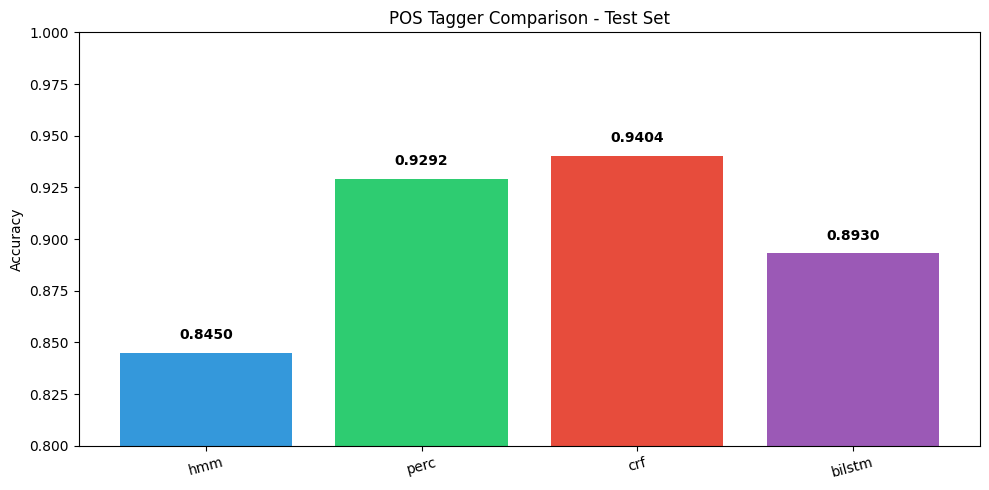

In [ ]:
# Plot accuracy bars
fig, ax = plt.subplots(figsize=(10, 5))
models = list(all_models.keys())
accuracies = [all_models[m]['accuracy'] for m in models]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

bars = ax.bar(models, accuracies, color=colors)
ax.set_ylabel('Accuracy')
ax.set_title('POS Tagger Comparison - Test Set')
ax.set_ylim([0.8, 1.0])

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f'accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

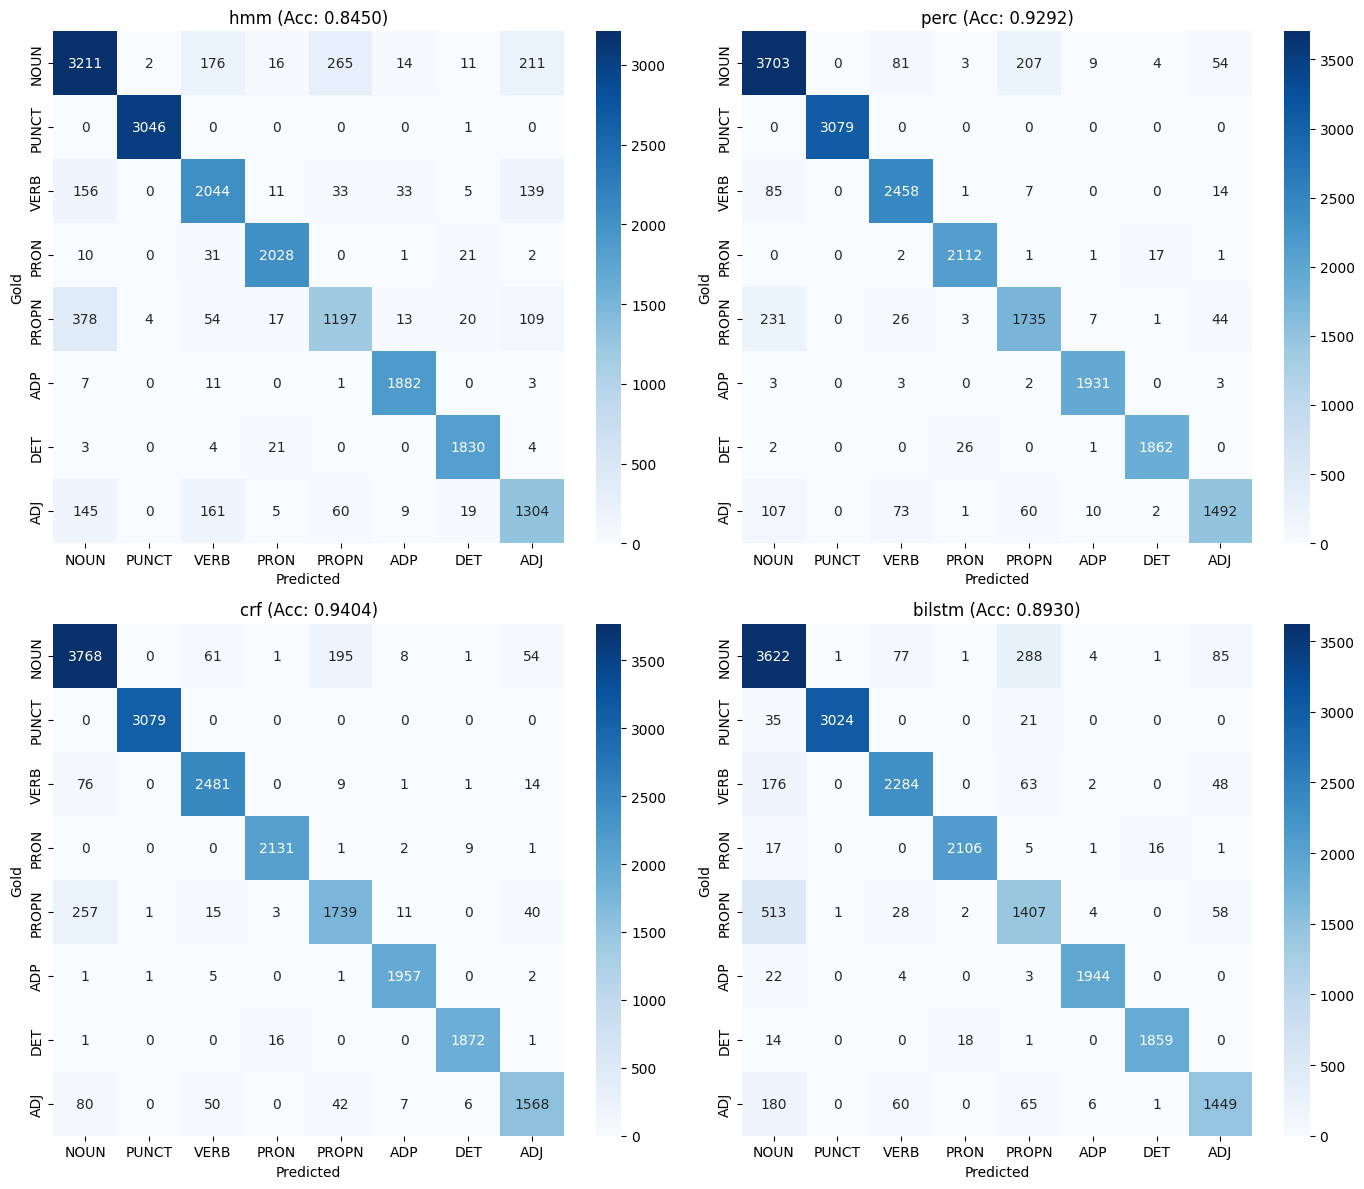

In [ ]:
# Plot confusion matrices for each model
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Get common tags
all_tags = list(hmm.tags)
if len(all_tags) > 8:
    # Get 8 most frequent tags
    tag_freq = Counter(hmm_gold)
    common_tags = [t for t, _ in tag_freq.most_common(8)]
else:
    common_tags = all_tags

for idx, (name, results) in enumerate(all_models.items()):
    filtered_pairs = [(g, p) for g, p in zip(results['gold'], results['pred']) if g in common_tags and p in common_tags]

    gold_filt, pred_filt = zip(*filtered_pairs)

    cm = confusion_matrix(gold_filt, pred_filt, labels=common_tags)

    sns.heatmap(cm, annot=True, fmt='d', xticklabels=common_tags,
                yticklabels=common_tags, cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name} (Acc: {results["accuracy"]:.4f})')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Gold')

plt.tight_layout()
plt.savefig(f'confusion_matricies.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def plot_bins(bin_names, hmm_bins, perc_bins, crf_bins, bilstm_bins, title):
    fig, ax = plt.subplots(figsize=(10, 6))

    x = np.arange(len(bin_names))
    width = 0.2

    hmm_accs = [hmm_bins[bin]['correct']/hmm_bins[bin]['total'] for bin in bin_names]
    perc_accs = [perc_bins[bin]['correct']/perc_bins[bin]['total'] for bin in bin_names]
    crf_accs = [crf_bins[bin]['correct']/crf_bins[bin]['total'] for bin in bin_names]
    bilstm_accs = [bilstm_bins[bin]['correct']/bilstm_bins[bin]['total'] for bin in bin_names]

    # Create bars with offset positions for each model
    bars_hmm = ax.bar(x - 1.5*width, hmm_accs, width, label=FULL_MODEL_NAMES['hmm'], color='#3498db', alpha=0.8)
    bars_perc = ax.bar(x - 0.5*width, perc_accs, width, label=FULL_MODEL_NAMES['perc'], color='#e74c3c', alpha=0.8)
    bars_crf = ax.bar(x + 0.5*width, crf_accs, width, label=FULL_MODEL_NAMES['crf'], color='#2ecc71', alpha=0.8)
    bars_bilstm = ax.bar(x + 1.5*width, bilstm_accs, width, label=FULL_MODEL_NAMES['bilstm'], color='#f39c12', alpha=0.8)

    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(bin_names)
    ax.legend()
    ax.set_ylim([0.7, 1.0])

    # Add value labels for all bars
    for bars, accs in zip([bars_hmm, bars_perc, bars_crf, bars_bilstm],
                        [hmm_accs, perc_accs, crf_accs, bilstm_accs]):
        for bar, val in zip(bars, accs):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=8, rotation=45)

    plt.tight_layout()
    plt.savefig(f'{'_'.join(title.lower().split())}.png', dpi=150, bbox_inches='tight')
    plt.show()

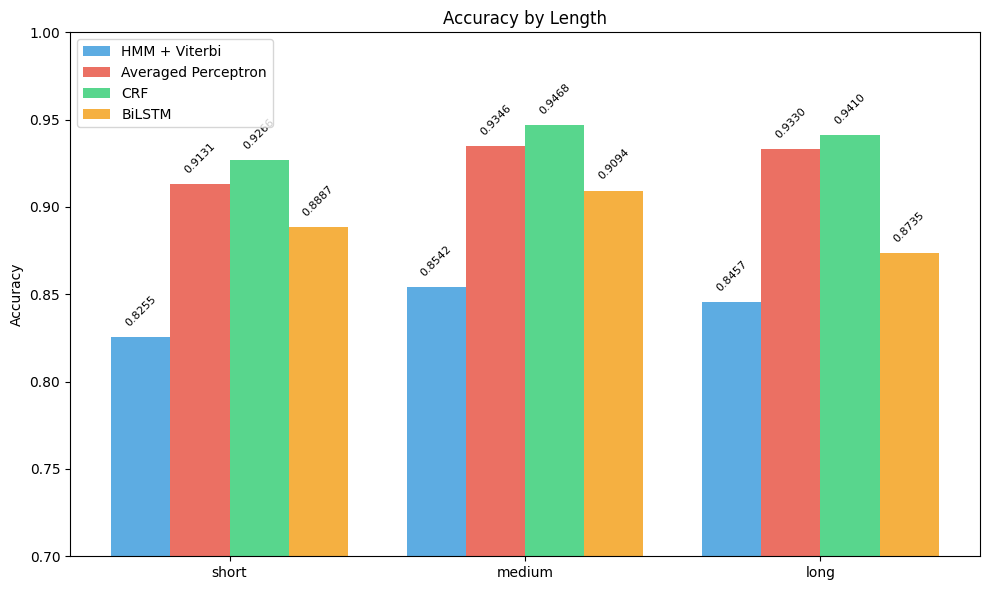

In [ ]:
plot_bins(['short', 'medium', 'long'], hmm_bins=hmm_length_bins, \
          perc_bins=perc_length_bins, crf_bins=crf_length_bins, \
          bilstm_bins=bilstm_length_bins, title="Accuracy by Length")

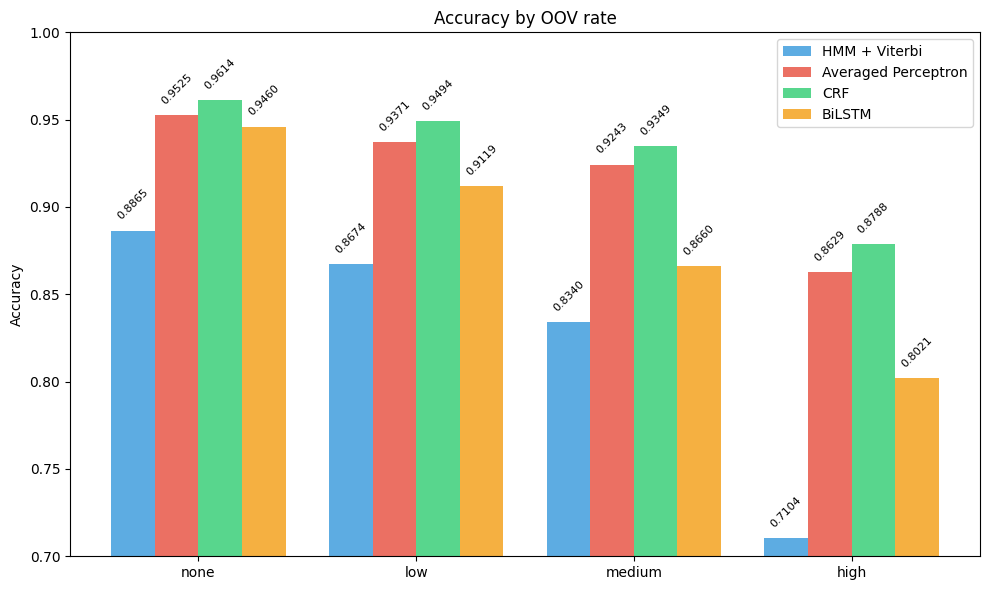

In [ ]:
plot_bins(['none', 'low', 'medium', 'high'], hmm_bins=hmm_oov_bins, \
          perc_bins=perc_oov_bins, crf_bins=crf_oov_bins, \
          bilstm_bins=bilstm_oov_bins, title="Accuracy by OOV rate")

In [ ]:
test_metadata[0]

{'sent_id': 0,
 'length': 7,
 'length_bin': 'short',
 'hmm_correct': 5,
 'perc_correct': 7,
 'crf_correct': 6,
 'bilstm_correct': 6,
 'oov_count': 2,
 'oov_rate': 0.2857142857142857,
 'oov_bin': 'medium'}

# Speed comparison

In [ ]:
from time import time

In [ ]:
for_time_test = [[w for w, _ in dev_sents[i]] for i in range(len(dev_sents))]
for_time_test[0]

['From', 'the', 'AP', 'comes', 'this', 'story', ':']

In [ ]:
hmm = HMMTagger(smoothing=0.01)
train_start = time()
hmm.train(train_sents)
train_finish = time()

eval_start = time()
for data in for_time_test:
    hmm.predict(data)
eval_finish = time()

hmm_train = train_finish - train_start
hmm_eval = eval_finish - eval_start

print(f"Training time: {hmm_train: .4f}")
print(f"Infernce time: {hmm_eval: .4f}")

Training time:  0.1887
Infernce time:  1.2449


In [ ]:
perceptron = AveragedPerceptronTagger(iterations=5)

train_start = time()
perceptron.train(train_sents)
train_finish = time()

eval_start = time()
for data in for_time_test:
    perceptron.predict(data)
eval_finish = time()

perc_train = train_finish - train_start
perc_eval = eval_finish - eval_start

print(f"Training time: {perc_train: .4f}")
print(f"Infernce time: {perc_eval: .4f}")

  Perceptron iteration 1/5
  Perceptron iteration 2/5
  Perceptron iteration 3/5
  Perceptron iteration 4/5
  Perceptron iteration 5/5
Training time:  62.3400
Infernce time:  1.8108


In [ ]:
crf = CRFTagger(algorithm='lbfgs', max_iterations=100, c1=0.1, c2=0.1)

train_start = time()
crf.train(train_sents, dev_sentences=dev_sents[:500])
train_finish = time()

eval_start = time()
for data in for_time_test:
    crf.predict(data)
eval_finish = time()

crf_train = train_finish - train_start
crf_eval = eval_finish - eval_start

print(f"Training time: {crf_train: .4f}")
print(f"Infernce time: {crf_eval: .4f}")

Preparing features for CRF...
Training CRF with 7262 sentences...
Algorithm: lbfgs, Max iterations: 100


loading training data to CRFsuite: 100%|██████████| 7262/7262 [00:02<00:00, 3531.92it/s]



Feature generation
type: CRF1d
feature.minfreq: 0.000000
feature.possible_states: 0
feature.possible_transitions: 1
0....1....2....3....4....5....6....7....8....9....10
Number of features: 164876
Seconds required: 0.650

L-BFGS optimization
c1: 0.100000
c2: 0.100000
num_memories: 6
max_iterations: 100
epsilon: 0.000010
stop: 10
delta: 0.000010
linesearch: MoreThuente
linesearch.max_iterations: 20

Iter 1   time=0.57  loss=299761.31 active=162829 feature_norm=1.00
Iter 2   time=0.30  loss=201354.22 active=160041 feature_norm=6.13
Iter 3   time=0.30  loss=161796.13 active=159717 feature_norm=7.91
Iter 4   time=0.29  loss=136381.26 active=161651 feature_norm=9.70
Iter 5   time=0.30  loss=114235.21 active=161210 feature_norm=12.46
Iter 6   time=0.29  loss=91713.71 active=159339 feature_norm=16.38
Iter 7   time=0.30  loss=74024.72 active=158280 feature_norm=20.30
Iter 8   time=0.31  loss=64967.50 active=156724 feature_norm=22.84
Iter 9   time=0.29  loss=54694.58 active=151212 feature_norm=

In [ ]:
bilstm = BiLSTMPOSTagger(
    embedding_dim=100,
    hidden_dim=128,
    num_layers=2,
    dropout=0.3,
    batch_size=32,
    epochs=8,
    learning_rate=0.001
)

train_start = time()
bilstm.train(train_sents, dev_sents[:500])
train_finish = time()

eval_start = time()
for data in for_time_test:
    bilstm.predict(data)
eval_finish = time()

bilstm_train = train_finish - train_start
bilstm_eval = eval_finish - eval_start

print(f"Training time: {bilstm_train: .4f}")
print(f"Infernce time: {bilstm_eval: .4f}")

Vocabulary size: 6404 words
Tag set size: 19 tags

Training BiLSTM for 8 epochs...
Model parameters: 1,276,067
Train samples: 7262, Batch size: 32
  Epoch 1, Batch 50/227, Loss: 1.6520, Acc: 0.2963
  Epoch 1, Batch 100/227, Loss: 1.1001, Acc: 0.4341
  Epoch 1, Batch 150/227, Loss: 0.8606, Acc: 0.5133
  Epoch 1, Batch 200/227, Loss: 0.7203, Acc: 0.5628
Epoch 1/8 - Train Loss: 1.3321, Train Acc: 0.5823, Dev Loss: 0.7093, Dev Acc: 0.7612
  Epoch 2, Batch 50/227, Loss: 0.6859, Acc: 0.7497
  Epoch 2, Batch 100/227, Loss: 0.6850, Acc: 0.7605
  Epoch 2, Batch 150/227, Loss: 0.7121, Acc: 0.7679
  Epoch 2, Batch 200/227, Loss: 0.5276, Acc: 0.7750
Epoch 2/8 - Train Loss: 0.6732, Train Acc: 0.7785, Dev Loss: 0.5162, Dev Acc: 0.8236
  Epoch 3, Batch 50/227, Loss: 0.4725, Acc: 0.8183
  Epoch 3, Batch 100/227, Loss: 0.5462, Acc: 0.8182
  Epoch 3, Batch 150/227, Loss: 0.5535, Acc: 0.8225
  Epoch 3, Batch 200/227, Loss: 0.3576, Acc: 0.8254
Epoch 3/8 - Train Loss: 0.5212, Train Acc: 0.8263, Dev Loss: 0

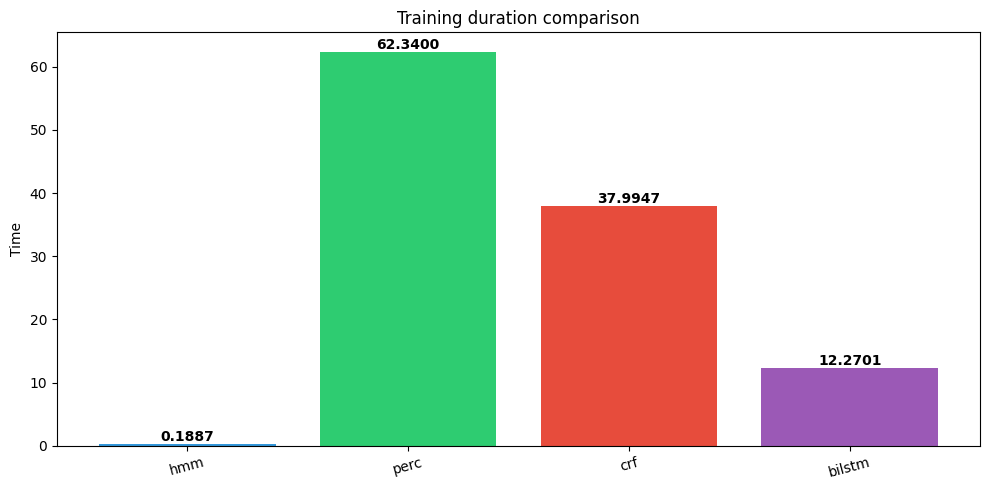

In [ ]:
# Plot bars
fig, ax = plt.subplots(figsize=(10, 5))
models = ['hmm', 'perc', 'crf', 'bilstm']
durations = [hmm_train, perc_train, crf_train, bilstm_train]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

bars = ax.bar(models, durations, color=colors)
ax.set_ylabel('Time')
ax.set_title('Training duration comparison')
ax.set_ylim()

# Add value labels on bars
for bar, dur in zip(bars, durations):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{dur:.4f}', ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f'training_duration.png', dpi=150, bbox_inches='tight')
plt.show()

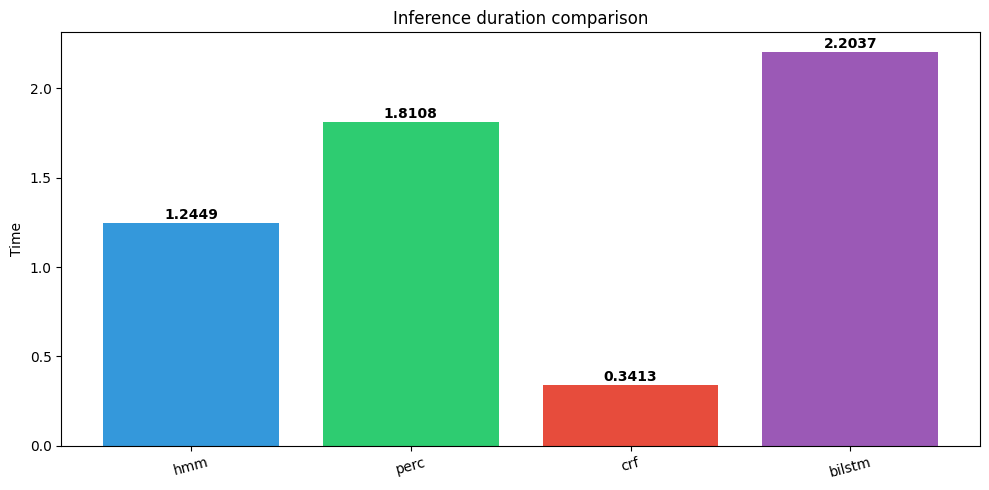

In [ ]:
# Plot bars
fig, ax = plt.subplots(figsize=(10, 5))
models = ['hmm', 'perc', 'crf', 'bilstm']
durations = [hmm_eval, perc_eval, crf_eval, bilstm_eval]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

bars = ax.bar(models, durations, color=colors)
ax.set_ylabel('Time')
ax.set_title('Inference duration comparison')
ax.set_ylim()

# Add value labels on bars
for bar, dur in zip(bars, durations):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{dur:.4f}', ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f'inference_duration.png', dpi=150, bbox_inches='tight')
plt.show()